<a href="https://colab.research.google.com/github/TcHaOcHeK/ML/blob/2/LR2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторная работа 2
Вариант 5 - Тищенко Т.Д.
гр. ПИН-231

# Задание 2
## Визуальный анализ данных
Цель работы: изучить программные средства, используемые для визуализации наборов данных

Датасет – wine.csv
В мире представлено множество вин, включая десертные вина, игристые вина, газированные вина, столовые вина и марочные вина. Возникает вопрос, как узнать, какое вино хорошее, а какое нет. В наборе данных 6497 наблюдений и всего 12 при-знаков.

Набор данных включает следующие атрибуты:
fixed acidity – уровень кислотности в вине
* volatile acidity – количество уксусной кислоты, присутствующей в вине
* citric acid – количество лимонной кислоты, присутствующей в вине
* residual sugar – количество сахара после ферментации
* chlorides – количество солей, присутствующих в вине
* free sulfur dioxide – количество SO2 в свободной форме
* total sulfur dioxide – количество свободных и связанных форм SO2
* density – плотность вина (масса/объем)
* pH – значение рН вина в диапазоне от 0 до 14
* sulphates – уровень содержания диоксида серы (SO2) в вине
* alcohol – количество алкоголя, присутствующего в вине
* quality – конечное качество упомянутого вина
* type – тип вина (красное, белое) – целевая переменная

### 1. Импортируем необходимые библиотеки

In [97]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

### 2. Импортируем набор данных из файла wine.csv и поместим его в объект DataFrame


In [98]:
data = pd.read_csv('wine.csv')
data.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5,red
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5,red
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7,red
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7,red
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5,red


### 3. Получим сводную информацию по датафрейму

In [99]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


### 4. Визуализация количественных признаков

Для каждого количественного признака построим гистограмму и диаграмму "Ящик с усами"

array([[<Axes: title={'center': 'volatile acidity'}>,
        <Axes: title={'center': 'citric acid'}>,
        <Axes: title={'center': 'residual sugar'}>],
       [<Axes: title={'center': 'chlorides'}>,
        <Axes: title={'center': 'free sulfur dioxide'}>,
        <Axes: title={'center': 'total sulfur dioxide'}>],
       [<Axes: title={'center': 'density'}>,
        <Axes: title={'center': 'pH'}>,
        <Axes: title={'center': 'sulphates'}>],
       [<Axes: title={'center': 'alcohol'}>, <Axes: >, <Axes: >]],
      dtype=object)

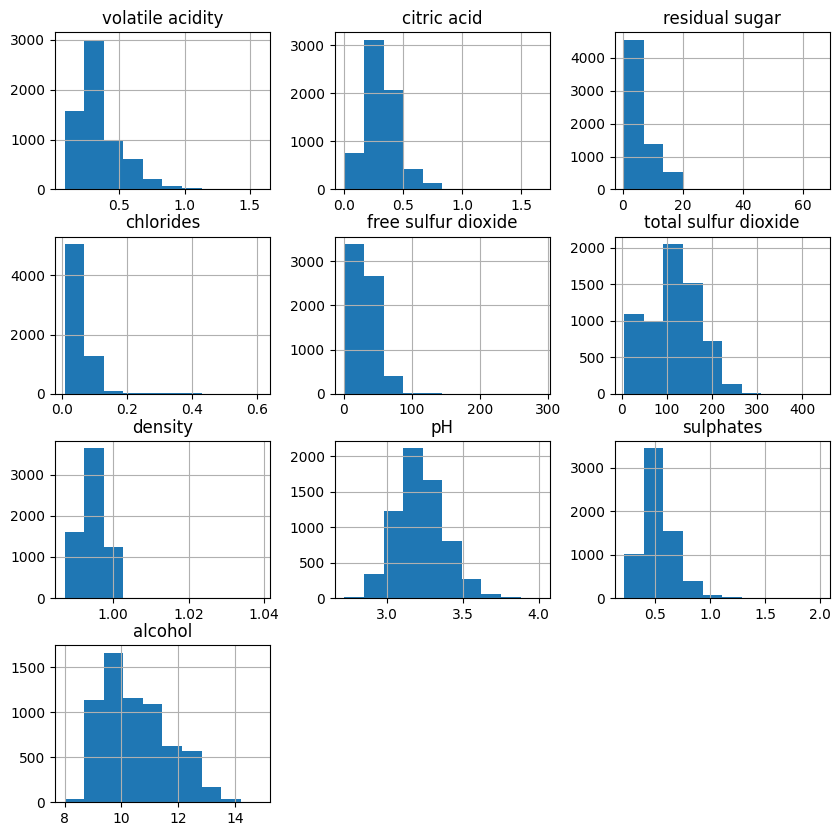

In [100]:
quantitative = ['volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
data[quantitative].hist(figsize = (10, 10))

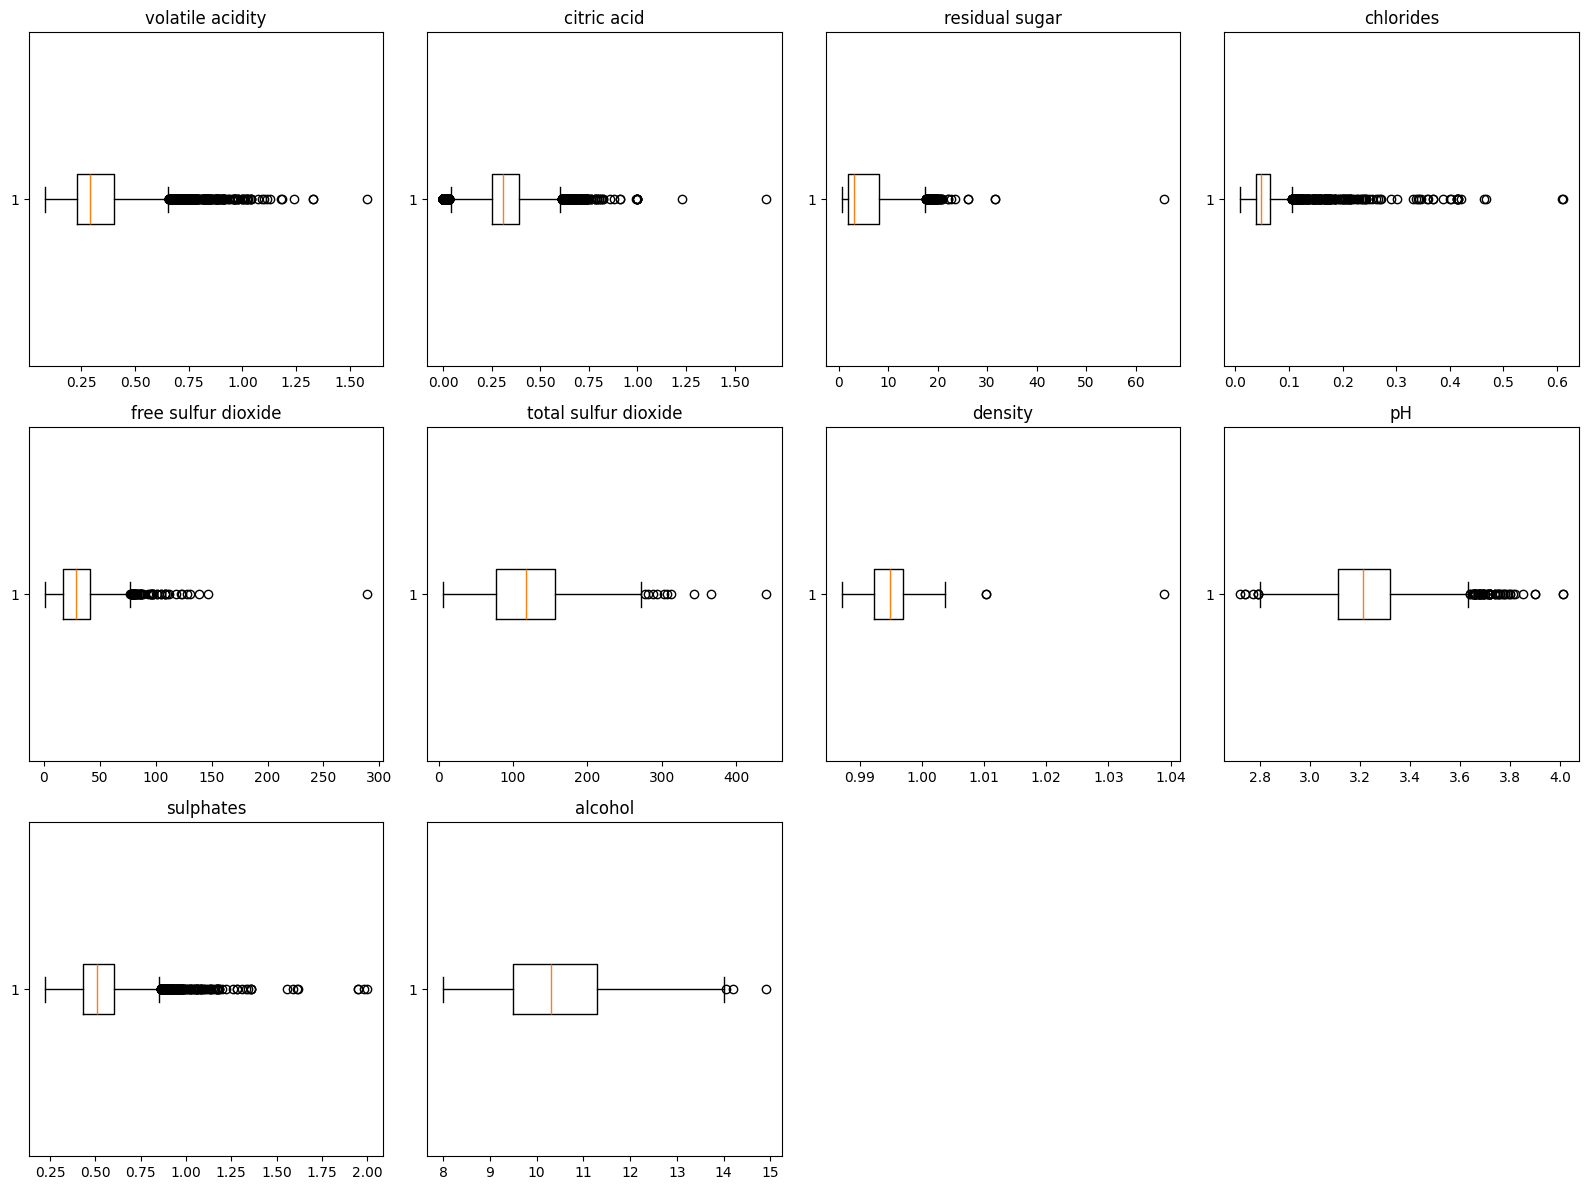

In [101]:
plt.figure(figsize=(16, 12))
for i, col in enumerate(quantitative, 1):
    plt.subplot(3, 4, i)
    plt.boxplot(data[col], vert=False)
    plt.title(col)
plt.tight_layout()
plt.show()

Построим так же гистограммы с разбивкой по целевой переменной

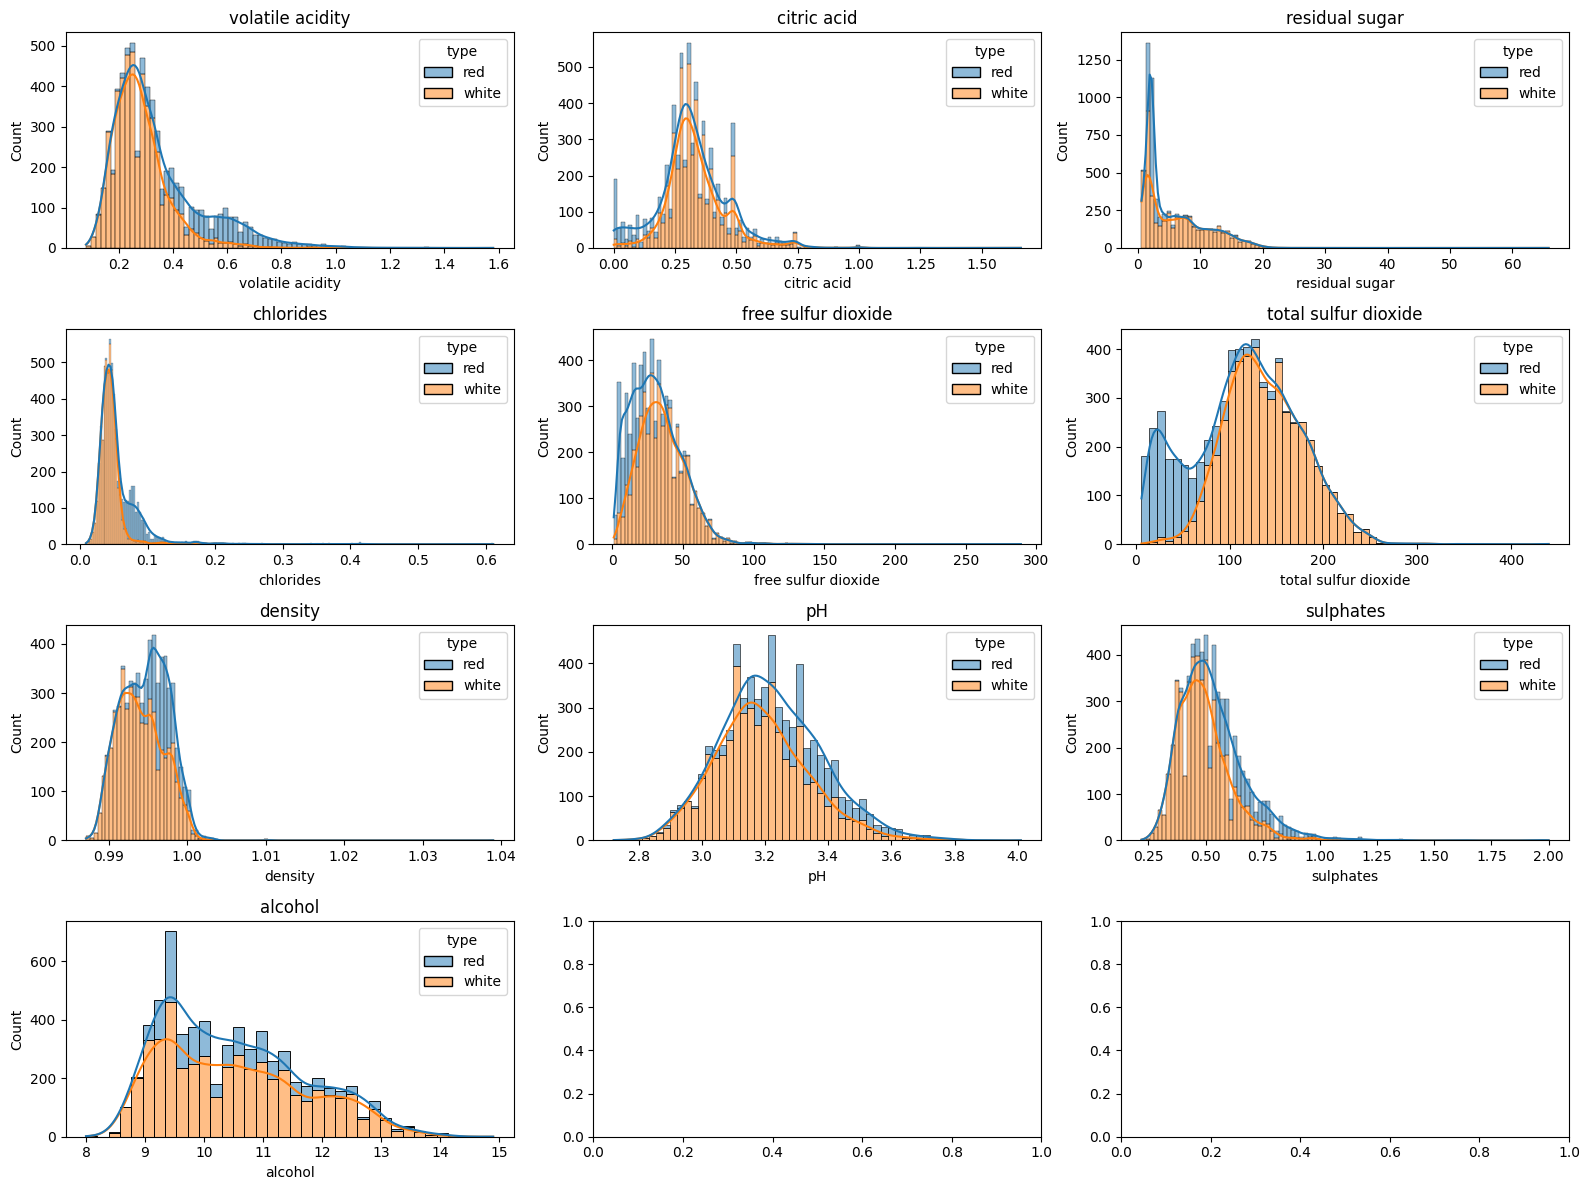

In [102]:
fig, axes = plt.subplots(4, 3, figsize=(16, 12))
axes = axes.flatten()
for i, col in enumerate(quantitative):
    sns.histplot(data=data, x=col, hue='type', kde=True, ax=axes[i], multiple="stack")
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

### 5. Визуализация категориальных признаков

Построим столбчатые диаграммы, показывающие:

*    распределение вин по целевой переменной type
*    распределение вин качества вин



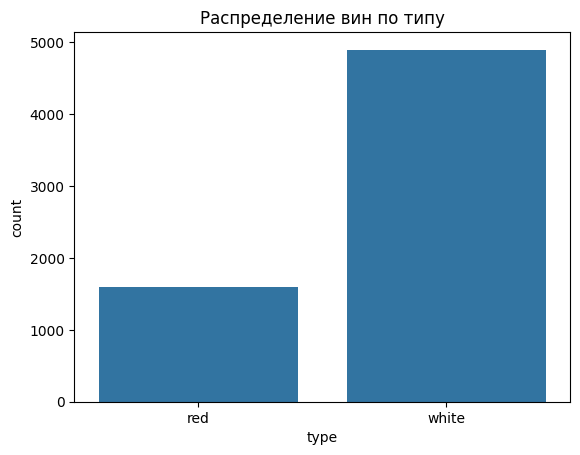

In [103]:
plt.title("Распределение вин по типу")
data.groupby('type').mean()
sns.countplot(x='type', data=data)
plt.show()

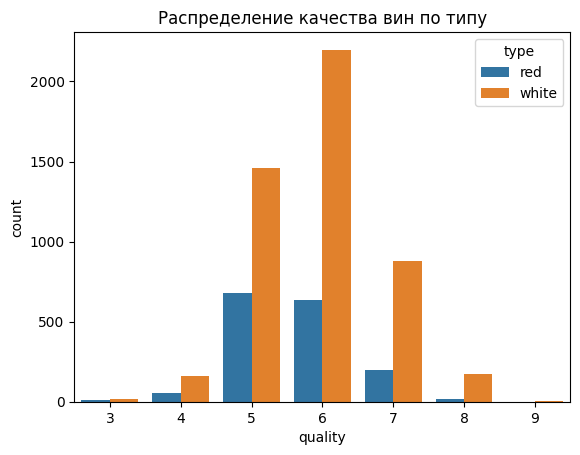

In [108]:
sns.countplot(x='quality', hue='type', data=data)
plt.title("Распределение качества вин по типу")
plt.show()

### 6. Визуализация взаимосвязанных признаков

Для колчественных данных: volatile acidity, citric acid, residual sugar и alcohol используем попарное сравнение признаков с разбивкой по целевой переменной

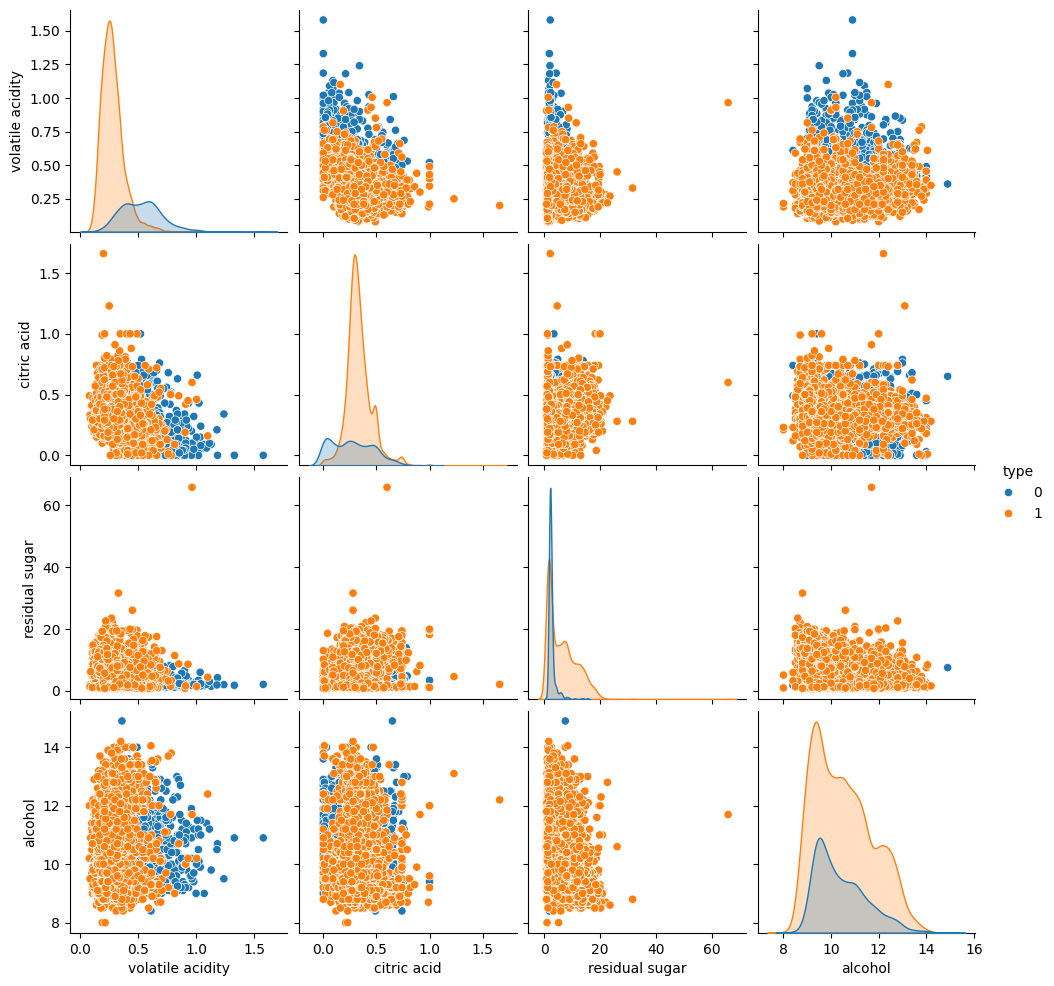

In [104]:
data_copy = data.copy()
data_copy['type'] = data_copy['type'].astype('category').cat.codes
sns.pairplot(data_copy[['volatile acidity', 'citric acid', 'residual sugar','alcohol','type']],hue='type')

### 7. Корреляция признаков

Для всех количественных признаков построим heatmap для визуализвции корреляции

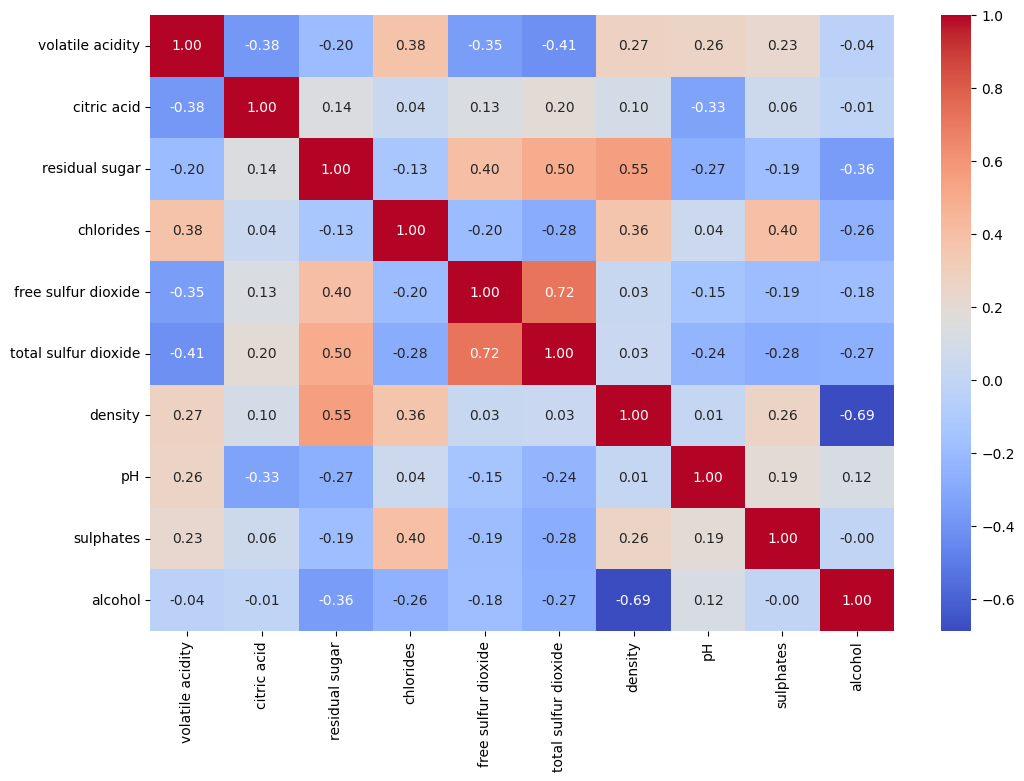

In [105]:
plt.figure(figsize=(12, 8))
correlation_data = data[quantitative].corr()
sns.heatmap(correlation_data, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

Вывод: В предоставленном датафрейме красные и белые наиболее явно различаются по таким признакам, как плотность, остаточный сахар и содержание алкоголя. Белые вина, как правило, имеют меньшую плотность, более высокий уровень остаточного сахара и несколько меньшее содержание алкоголя по сравнению с красными. Это означает, что эти признаки могут быть использованы для надёжного различения типов вин, а модели классификации на их основе будут обладать высокой точностью.